In [19]:
import sys
print(sys.executable)
!{sys.executable} -m pip install kagglehub

C:\Users\yudhi\AppData\Local\Programs\Python\Python311\python.exe
  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/a4/8e/4077b08b95a1f8302c694a8b399bd413815fbe89045c41e6e08cd7d9439a/kagglehub-0.3.13-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/68.3 kB ? eta -:--:--
   ---------------------------------------- 68.3/68.3 kB 1.8 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import kagglehub

path = kagglehub.dataset_download(
    "olafkrastovski/handwritten-digits-0-9"
)

print("Dataset path:", path)

C:\Users\yudhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|█████████████████████████████████████████████████████████████████████████████| 66.7M/66.7M [00:33<00:00, 2.12MB/s]

Extracting files...


Dataset path: C:\Users\yudhi\.cache\kagglehub\datasets\olafkrastovski\handwritten-digits-0-9\versions\2


In [21]:
import os
os.listdir(path)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [23]:
import numpy as np
from PIL import Image

X = []
y = []

for label in range(10):
    folder = os.path.join(path, str(label))
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)

        img = Image.open(img_path).convert("L")  # grayscale
        img = img.resize((28, 28))               # resize 28x28
        img = np.array(img) / 255.0              # normalisasi

        X.append(img.flatten())
        y.append(label)

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21555, 784)
y shape: (21555,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)


Train: (17244, 784)
Test : (4311, 784)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print("Model selesai dilatih")

Model selesai dilatih


In [26]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5720250521920668

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.76      0.72       392
           1       0.64      0.69      0.66       489
           2       0.59      0.61      0.60       467
           3       0.59      0.60      0.60       446
           4       0.52      0.58      0.55       426
           5       0.50      0.46      0.48       419
           6       0.58      0.61      0.59       432
           7       0.55      0.57      0.56       402
           8       0.53      0.41      0.46       427
           9       0.50      0.42      0.46       411

    accuracy                           0.57      4311
   macro avg       0.57      0.57      0.57      4311
weighted avg       0.57      0.57      0.57      4311



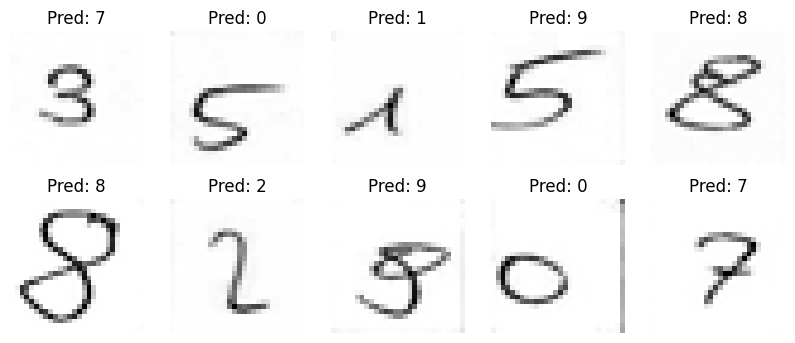

In [28]:
plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap="gray")
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis("off")
plt.show()
